In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids

In [27]:
RUTA_IMG = "flores-verano-jardin.jpg" # Remplaza con la ruta real a tu imagen

In [28]:
import numpy as np
from PIL import Image

def preparar_imagen_para_kmeans(ruta_imagen):
    """
    Convierte una imagen en un array 2D procesable por KMeans,
    manteniendo todos los colores y píxeles exactos.
    """
    # 1. Cargar la imagen y asegurar que esté en formato RGB (3 canales)
    imagen = Image.open(ruta_imagen).convert('RGB')

    # 2. Convertir la imagen a un arreglo de NumPy
    arreglo_imagen = np.array(imagen)

    # 3. Extraer las dimensiones originales (necesarias para reconstruir la imagen después)
    alto, ancho, canales = arreglo_imagen.shape

    # 4. Aplanar el arreglo de 3D a 2D: (alto * ancho, 3)
    arreglo_2d = arreglo_imagen.reshape((alto * ancho, canales))

    # 5. Normalizar los valores entre 0 y 1 (opcional, pero recomendado para KMeans)
    # Se usa float32 para no consumir memoria excesiva sin perder precisión
    arreglo_procesable = np.float32(arreglo_2d) / 255.0

    return arreglo_procesable, (alto, ancho, canales)

# --- Ejemplo de uso ---
matriz_pixeles, dimensiones_originales = preparar_imagen_para_kmeans(RUTA_IMG)

In [29]:
import numpy as np
from PIL import Image
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

def preparar_imagen_redimensionada(ruta_imagen, nuevo_ancho, nuevo_alto):
    """
    Redimensiona la imagen conservando la calidad y la estructura para KMeans.
    """
    imagen = Image.open(ruta_imagen).convert('RGB')

    # Redimensionar usando Lanczos para mantener la mejor calidad posible
    imagen = imagen.resize((nuevo_ancho, nuevo_alto), Image.Resampling.LANCZOS)

    arreglo_imagen = np.array(imagen)
    alto, ancho, canales = arreglo_imagen.shape

    # Aplanar y normalizar
    arreglo_procesable = np.float32(arreglo_imagen.reshape((alto * ancho, canales))) / 255.0

    return arreglo_procesable, (alto, ancho, canales)


def calcular_mejor_k_silueta(arreglo_procesable, k_min=2, k_max=10, max_muestras=10000):
    """
    Calcula el mejor K usando el coeficiente de silueta.
    Usa submuestreo y MiniBatchKMeans para que sea computacionalmente viable.
    """
    mejor_k = k_min
    mejor_puntaje = -1
    resultados_k = {}

    # Si la imagen es más grande que 'max_muestras', tomamos una muestra aleatoria
    # para no colapsar el cálculo de la silueta (que es O(n^2))
    n_pixeles = arreglo_procesable.shape[0]
    if n_pixeles > max_muestras:
        indices = np.random.choice(n_pixeles, max_muestras, replace=False)
        muestra_evaluacion = arreglo_procesable[indices]
    else:
        muestra_evaluacion = arreglo_procesable

    for k in range(k_min, k_max + 1):
        # MiniBatchKMeans es ideal para procesamiento de imágenes
        kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=3072, n_init='auto')

        # Entrenamos y predecimos solo sobre la muestra
        etiquetas = kmeans.fit_predict(muestra_evaluacion)

        # Evitar errores si un K produce un solo cluster
        if len(np.unique(etiquetas)) > 1:
            puntaje = silhouette_score(muestra_evaluacion, etiquetas)
            resultados_k[k] = puntaje

            if puntaje > mejor_puntaje:
                mejor_puntaje = puntaje
                mejor_k = k

    return mejor_k, mejor_puntaje, resultados_k

# --- Ejemplo de uso ---
# 1. Redimensionar a 800x600 (ancho x alto)
matriz_pixeles, dimensiones = preparar_imagen_redimensionada(RUTA_IMG, 8000, 6000)

# 2. Calcular mejor K probando entre 2 y 8 colores
k_optimo, score, historial = calcular_mejor_k_silueta(matriz_pixeles, k_min=2, k_max=8)
print(f"El K óptimo es {k_optimo} con un score de {score:.4f}")
k_optimo = 4

El K óptimo es 2 con un score de 0.6734


In [30]:
import numpy as np
from PIL import Image
from sklearn.cluster import MiniBatchKMeans

def extraer_paleta_colores(ruta_imagen, k_optimo):
    """
    Extrae los colores representativos (paleta) de la imagen original.
    Transforma la imagen 3D a 2D para KMeans y luego devuelve los RGB de cada clúster.
    """
    # 1. Cargar imagen y convertir a arreglo de NumPy (3D: Alto x Ancho x 3)
    imagen = Image.open(ruta_imagen).convert('RGB')
    arreglo_imagen = np.array(imagen)
    alto, ancho, canales = arreglo_imagen.shape

    # 2. Aplanar de 3D a 2D y normalizar
    arreglo_2d = np.float32(arreglo_imagen.reshape((alto * ancho, canales))) / 255.0

    # 3. Entrenar el modelo con la imagen completa (o usar el submuestreo si es gigante)
    # Se recomienda MiniBatchKMeans por la cantidad masiva de píxeles en la imagen original
    kmeans = MiniBatchKMeans(n_clusters=k_optimo, random_state=42, batch_size=3072, n_init='auto')
    kmeans.fit(arreglo_2d)

    # 4. Extraer los centroides (los colores de la paleta en escala 0 a 1)
    centros_normalizados = kmeans.cluster_centers_

    # 5. Convertir la paleta de vuelta a formato RGB tradicional (0 a 255, enteros)
    paleta_rgb = (centros_normalizados * 255).astype(np.uint8)

    return paleta_rgb, kmeans.labels_, (alto, ancho, canales)

# --- Ejemplo de uso ---
# Supongamos que tu K óptimo calculado en el paso anterior fue 5
paleta, etiquetas, dimensiones = extraer_paleta_colores(RUTA_IMG
                                                        , k_optimo)

print("Paleta de colores (RGB):")
for color in paleta:
    print(color)

Paleta de colores (RGB):
[242 183 243]
[ 35 103   6]
[197  40 159]
[106 155  25]
[15 32  6]


In [31]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def visualizar_resultados_kmeans(ruta_imagen, paleta_rgb, etiquetas, dimensiones):
    """
    Visualiza en un Jupyter Notebook:
    1. La imagen original.
    2. La imagen reconstruida usando solo la paleta de colores.
    3. La paleta de colores extraída (corregido el aspecto visual).
    """

    # --- 1. Preparar Imagen Original ---
    imagen_original_pil = Image.open(ruta_imagen).convert('RGB')
    imagen_original_np = np.array(imagen_original_pil)

    # --- 2. Reconstruir Imagen Cuantizada ---
    imagen_flat_reconstruida = paleta_rgb[etiquetas]
    imagen_reconstruida_3d = imagen_flat_reconstruida.reshape(dimensiones)

    # --- 3. Crear Visualización de la Paleta ---
    k_colores = len(paleta_rgb)
    altura_swatch = 100

    paleta_reshaped = paleta_rgb.reshape((1, k_colores, 3))
    paleta_visualizacion = np.tile(paleta_reshaped, (altura_swatch, 1, 1))

    # --- 4. Configurar el Plot de Matplotlib ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Plot 1: Original
    axes[0].imshow(imagen_original_np)
    axes[0].set_title("Imagen Original")
    axes[0].axis('off')

    # Plot 2: Reconstruida
    axes[1].imshow(imagen_reconstruida_3d)
    axes[1].set_title(f"Imagen Cuantizada ({k_colores} colores)")
    axes[1].axis('off')

    # Plot 3: Paleta (AQUÍ ESTÁ LA CORRECCIÓN: aspect='auto')
    axes[2].imshow(paleta_visualizacion, aspect='auto')
    axes[2].set_title("Paleta de Colores Extraída")

    # Centrar los números de los índices de color
    axes[2].set_xticks(np.arange(k_colores))
    axes[2].set_yticks([])

    plt.tight_layout()
    plt.show()

Calculando paleta para K=5...
¡Cálculo finalizado!


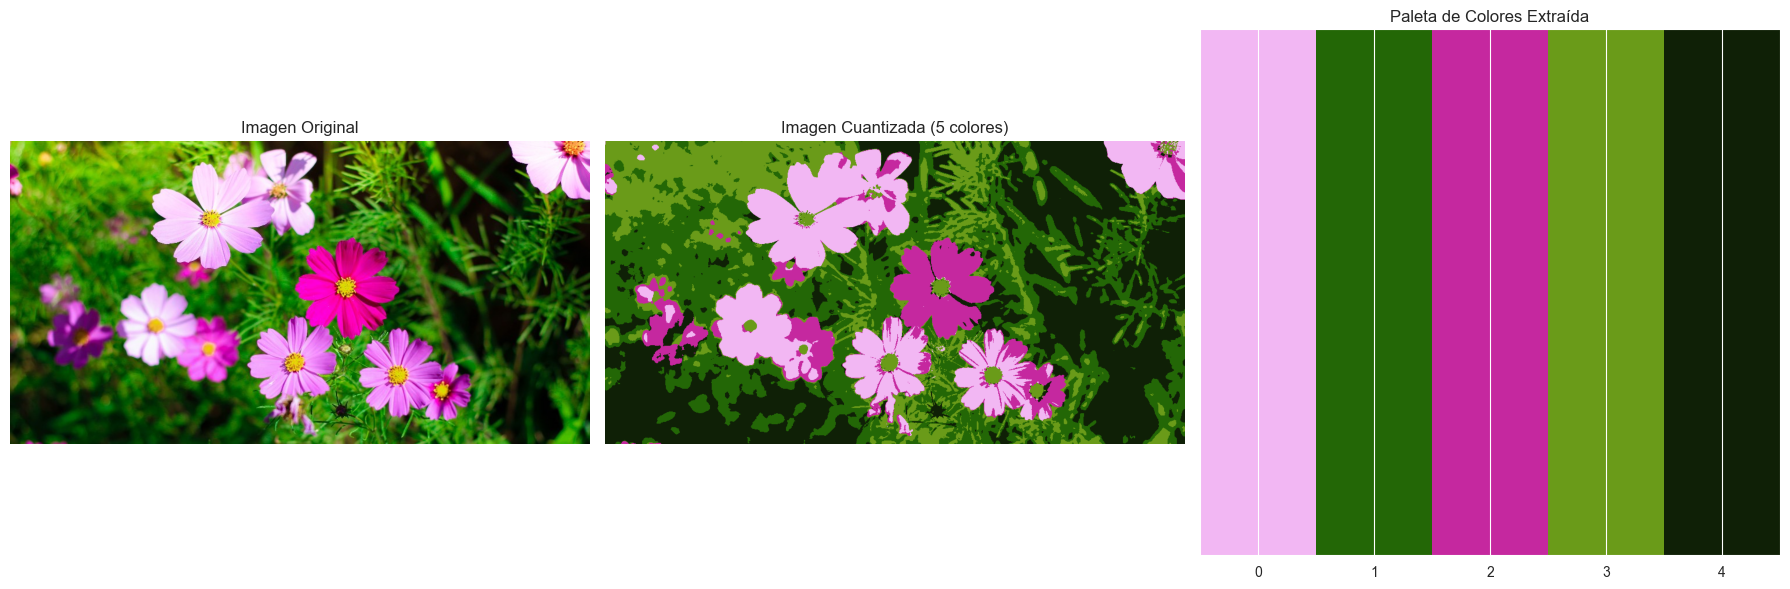

In [32]:
# --- Parámetros ---
K_OPTIMO_CALCULADO = k_optimo # Supongamos que la silueta te dio 5 en el paso anterior

# --- 1. Ejecución del Algoritmo ---
# Usamos la función que definimos en el paso anterior
print(f"Calculando paleta para K={K_OPTIMO_CALCULADO}...")
paleta_final_rgb, etiquetas_pixeles, dims_originales = extraer_paleta_colores(RUTA_IMG, K_OPTIMO_CALCULADO)
print("¡Cálculo finalizado!")

# (Opcional) Ver los colores RGB numéricamente
# print("\nColores RGB extraídos:")
# print(paleta_final_rgb)

# --- 2. Visualización ---
# Usamos la nueva función de visualización
visualizar_resultados_kmeans(
    ruta_imagen=RUTA_IMG,
    paleta_rgb=paleta_final_rgb,
    etiquetas=etiquetas_pixeles,
    dimensiones=dims_originales
)

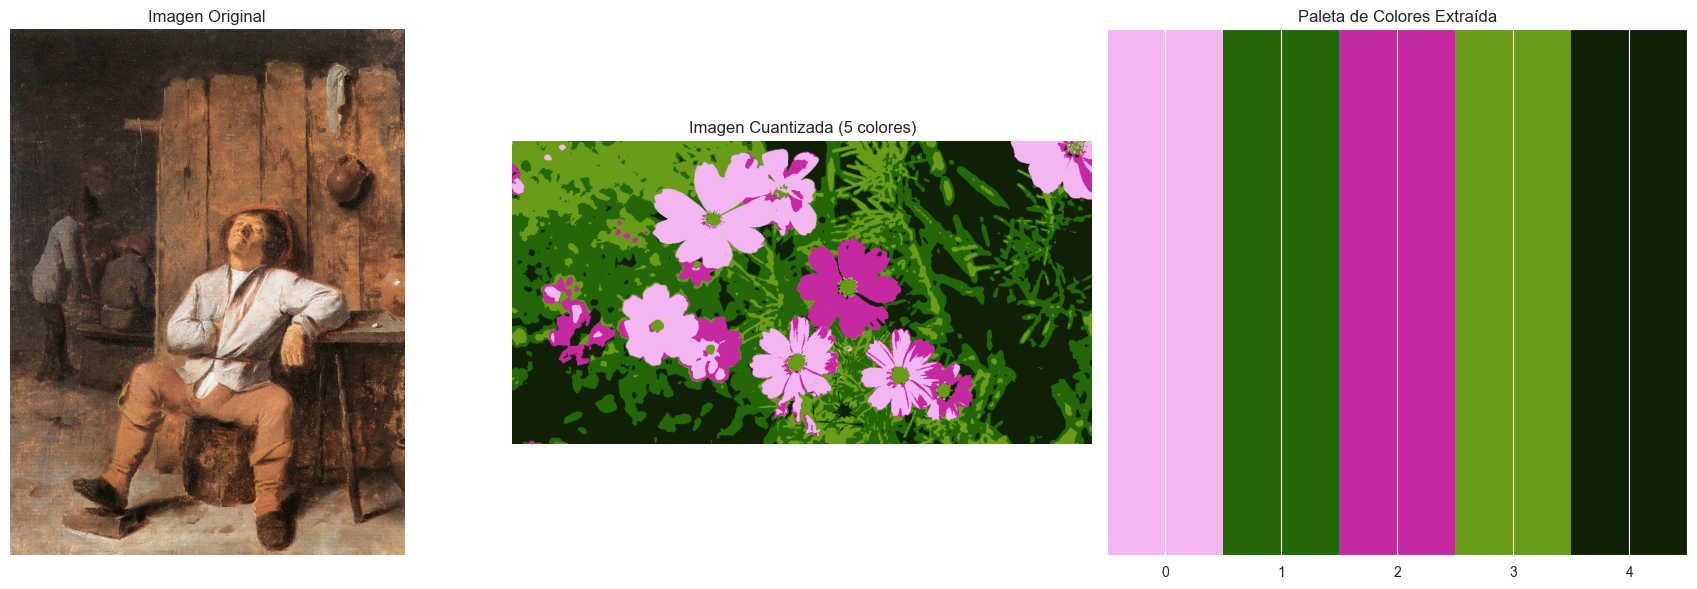

In [35]:
# --- Parámetros ---
K_OPTIMO_CALCULADO = k_optimo

# --- 1. Ejecución del Algoritmo ---
# Usamos la función que definimos en el paso anterior
print(f"Calculando paleta para K={K_OPTIMO_CALCULADO}...")
paleta_final_rgb, etiquetas_pixeles, dims_originales = extraer_paleta_colores(RUTA_IMG, K_OPTIMO_CALCULADO)
print("¡Cálculo finalizado!")

# (Opcional) Ver los colores RGB numéricamente
# print("\nColores RGB extraídos:")
# print(paleta_final_rgb)

# --- 2. Visualización ---
# Usamos la nueva función de visualización
visualizar_resultados_kmeans(
    ruta_imagen=RUTA_IMG,
    paleta_rgb=paleta_final_rgb,
    etiquetas=etiquetas_pixeles,
    dimensiones=dims_originales
)

Cargando imagen original y preparando datos...
Calculando métricas. Esto puede tomar un momento...


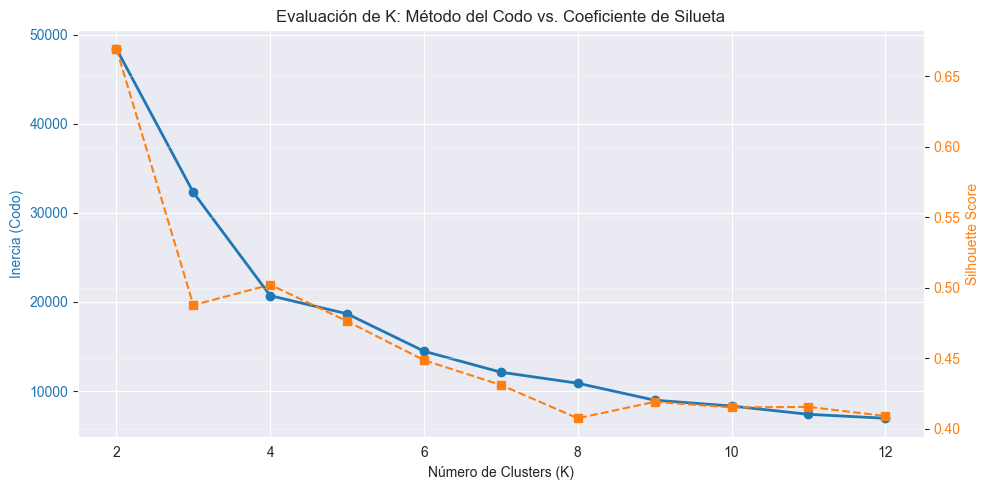

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

def evaluar_k_codo_silueta(ruta_imagen, k_min=2, k_max=10):
    """
    Evalúa y grafica el Método del Codo (Inercia) y la Silueta
    usando la imagen original sin redimensionar.
    """
    print("Cargando imagen original y preparando datos...")
    imagen = Image.open(ruta_imagen).convert('RGB')
    arreglo_imagen = np.array(imagen)
    alto, ancho, canales = arreglo_imagen.shape

    # Aplanar y normalizar la imagen ORIGINAL completa
    arreglo_2d = np.float32(arreglo_imagen.reshape((alto * ancho, canales))) / 255.0

    inercia = []
    siluetas = []
    rango_k = range(k_min, k_max + 1)

    # Muestra para la silueta (O(N^2) es inviable para la imagen completa)
    n_pixeles = arreglo_2d.shape[0]
    indices = np.random.choice(n_pixeles, min(10000, n_pixeles), replace=False)
    muestra_silueta = arreglo_2d[indices]

    print("Calculando métricas. Esto puede tomar un momento...")
    for k in rango_k:
        # Usamos batch_size grande para aprovechar el hardware
        kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=4096, n_init='auto')
        kmeans.fit(arreglo_2d) # Ajuste con TODOS los píxeles

        inercia.append(kmeans.inertia_)

        # Predicción solo sobre la muestra para la silueta
        etiquetas_muestra = kmeans.predict(muestra_silueta)
        if len(np.unique(etiquetas_muestra)) > 1:
            siluetas.append(silhouette_score(muestra_silueta, etiquetas_muestra))
        else:
            siluetas.append(-1)

    # --- Graficar ---
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Gráfica del Codo (Inercia)
    color = 'tab:blue'
    ax1.set_xlabel('Número de Clusters (K)')
    ax1.set_ylabel('Inercia (Codo)', color=color)
    ax1.plot(rango_k, inercia, marker='o', color=color, linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color)

    # Gráfica de Silueta (eje Y secundario)
    ax2 = ax1.twinx()
    color = 'tab:orange'
    ax2.set_ylabel('Silhouette Score', color=color)
    ax2.plot(rango_k, siluetas, marker='s', color=color, linestyle='dashed')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title("Evaluación de K: Método del Codo vs. Coeficiente de Silueta")
    fig.tight_layout()
    plt.grid(True, alpha=0.3)
    plt.show()

# Ejecución:
evaluar_k_codo_silueta(RUTA_IMG, k_min=2, k_max=12)

Cargando imagen original y preparando datos...
Calculando inercia para rango de k...


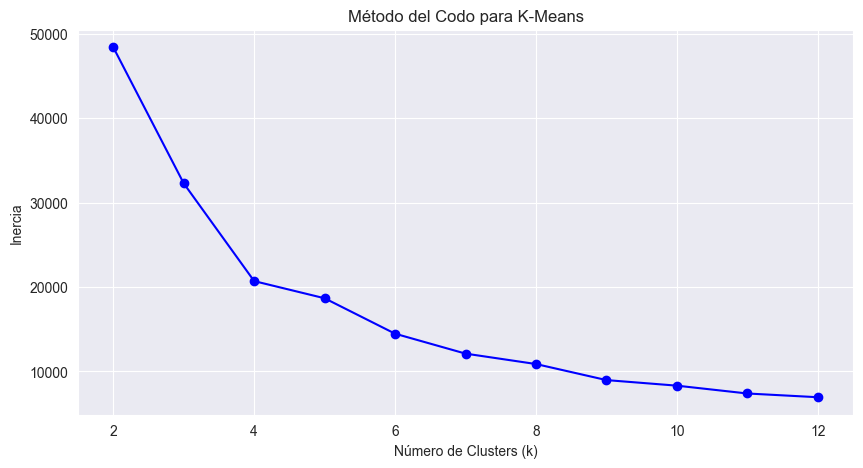

El k óptimo calculado matemáticamente es: 4


4

In [36]:
def evaluar_k_codo(ruta_imagen, k_min=2, k_max=10):
    """
    Evalúa y grafica el Método del Codo (Inercia) y retorna el k óptimo calculado matemáticamente.
    """
    print("Cargando imagen original y preparando datos...")
    imagen = Image.open(ruta_imagen).convert('RGB')
    arreglo_imagen = np.array(imagen)
    alto, ancho, canales = arreglo_imagen.shape

    # Aplanar y normalizar
    arreglo_2d = np.float32(arreglo_imagen.reshape((alto * ancho, canales))) / 255.0

    inercia = []
    rango_k = range(k_min, k_max + 1)

    print("Calculando inercia para rango de k...")
    for k in rango_k:
        kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=4096, n_init='auto')
        kmeans.fit(arreglo_2d)
        inercia.append(kmeans.inertia_)

    # --- Graficar ---
    plt.figure(figsize=(10, 5))
    plt.plot(rango_k, inercia, marker='o', linestyle='-', color='b')
    plt.xlabel('Número de Clusters (k)')
    plt.ylabel('Inercia')
    plt.title('Método del Codo para K-Means')
    plt.grid(True)
    plt.show()

    # --- Calcular K Óptimo (Método de la distancia máxima a la recta secante) ---
    # Coordenadas de la curva
    x = list(rango_k)
    y = inercia

    # Puntos extremos de la recta secante
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])

    distancias = []
    for i in range(len(x)):
        p0 = np.array([x[i], y[i]])
        # Distancia de un punto p0 a la recta definida por p1 y p2
        # d = |cross_product((p2-p1), (p1-p0))| / |p2-p1|
        distancia = np.abs(np.cross(p2 - p1, p1 - p0)) / np.linalg.norm(p2 - p1)
        distancias.append(distancia)

    # El índice del punto con mayor distancia corresponde al codo
    indice_optimo = np.argmax(distancias)
    k_optimo = x[indice_optimo]

    print(f"El k óptimo calculado matemáticamente es: {k_optimo}")
    return k_optimo

evaluar_k_codo("flores-verano-jardin.jpg", k_min=2, k_max=12)